In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [51]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/B_varreduction/AVERAGE_Station_pca_variables.csv")
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/station_pca_variables.csv")
#weathercluster_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/weather_7.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/AAFINAL_KMMFIT_4_msl.csv")
Static_contr = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/static_contributers.csv")

stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)
GEV_clusters["cluster_id"] = GEV_clusters["cluster"]

label_df = GEV_clusters[["station", "cluster", "cluster_id", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on=["station","lat", "lon"], how="inner")
model_df = model_df.merge(Static_contr, on=["station","lat", "lon"], how="inner")

In [52]:
import numpy as np
import pandas as pd

def cohens_d(x, y):
    """Compute Cohen's d for two independent samples."""
    x = x.dropna()
    y = y.dropna()
    
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    
    mean_x, mean_y = np.mean(x), np.mean(y)
    
    # pooled standard deviation
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )
    
    if pooled_std == 0:
        return 0
    
    return (mean_x - mean_y) / pooled_std

In [53]:
num_cols = [
    'bearing_deg_0.1x0.1_minus_wind_dir',
    'wind_wave_diff',
    'swh',
    'wind_dir'
]

In [57]:
model_df.columns

Index(['Unnamed: 0_x', 'wind_wave_alignment', 'tp',
       'bearing_deg_0.1x0.1_minus_wind_dir',
       'bearing_deg_10x10_minus_wind_dir', 'bearing_deg_1x1_minus_mwd',
       'bearing_deg_1x1_minus_wind_dir', 'bearing_deg_3x3_minus_wind_dir',
       'bearing_deg_3x3_minus_mwd', 'msl', 'v10_abs', 'sp', 'wind_dir',
       'bearing_deg_0.1x0.1_minus_mwd', 'bearing_deg_0.1x0.1',
       'bearing_deg_10x10_minus_mwd', 'bearing_deg_3x3', 'coastal_normal2_deg',
       'bay_normal2_deg', 'mwd', 'wind_vs_bay_normal_diff_deg',
       'wind_vs_coastal_normal_diff_deg', 'u10_abs', 'bearing_deg_10x10',
       'sst', 'bearing_deg_1x1', 'bay_normal1_deg', 'wind_more_bayshore_deg',
       't2m', 'wind_more_coastalshore_deg', 'bay_bearing_deg',
       'wind_wave_diff', 'coastal_normal1_deg', 'coastal_bearing_deg',
       'local_slope_max_mpm_3x3', 'tau_v', 'd2m', 'mwp', 'aspect_deg_mean_3x3',
       'aspect_deg_mean_1x1', 'v10', 'wind_to_mean_deg',
       'corridor_depth_max_m_0.1x0.1', 'aspect_deg_mea

In [124]:
df=model_df.copy()

drop_cols = {"station", "cluster_x", "cluster_y"}
#drop_cols = {"station"}
forbidden_substrings = ("sea_level","residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed", "name", "Unnamed", 'HYRIV' , "gev", "ks", "kuiper", "r2", "dist_to_CVI_m",
                        "dist_to_morpho_m", "H", "HYRIV_ID", "HYR", "GEOM", "POINT", "index", "geometry")
# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols
df= df.drop(columns=[c for c in cols_to_drop if c in df.columns])

num_cols = df.select_dtypes(include=['number']).columns.tolist()

# remove identifiers if present
exclude = ['cluster_id', 'Unnamed: 0_x']
num_cols = [col for col in num_cols if col not in exclude]

results = []

clusters = df['cluster_id'].dropna().unique()

for cluster in clusters:
    df_cluster = df[df['cluster_id'] == cluster]
    df_rest = df[df['cluster_id'] != cluster]
    
    for col in num_cols:
        d = cohens_d(df_cluster[col], df_rest[col])
        
        results.append({
            'cluster_id': cluster,
            'variable': col,
            'cohens_d': d,
            'abs_d': abs(d)
        })

effect_df = pd.DataFrame(results)

# top 3 per cluster
top_features = (
    effect_df
    .sort_values(["cluster_id", "abs_d"], ascending=[True, False])
    .groupby("cluster_id", group_keys=False)
    .head(3)
    .copy()
)

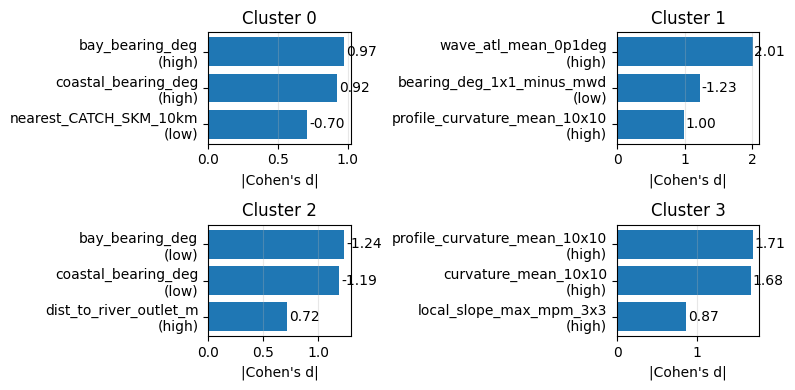

In [127]:
import math
import matplotlib.pyplot as plt

plot_df = top_features.copy()
clusters = sorted(plot_df["cluster_id"].unique())

ncols = 2
nrows = math.ceil(len(clusters) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 2 * nrows), squeeze=False)
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    ax = axes[i]
    tmp = (
        plot_df[plot_df["cluster_id"] == cluster]
        .sort_values("abs_d", ascending=True)
    )

    ax.barh(range(len(tmp)), tmp["abs_d"])

    ax.set_yticks(range(len(tmp)))
    ax.set_yticklabels([
        f"{v}\n({'high' if d > 0 else 'low'})"
        for v, d in zip(tmp["variable"], tmp["cohens_d"])
    ])

    for j, dval in enumerate(tmp["cohens_d"]):
        ax.text(
            abs(dval) + 0.02,
            j,
            f"{dval:.2f}",
            va="center"
        )

    ax.set_title(f"Cluster {cluster}")
    ax.set_xlabel("|Cohen's d|")
    ax.grid(axis="x", alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Now do it for only the weather variables

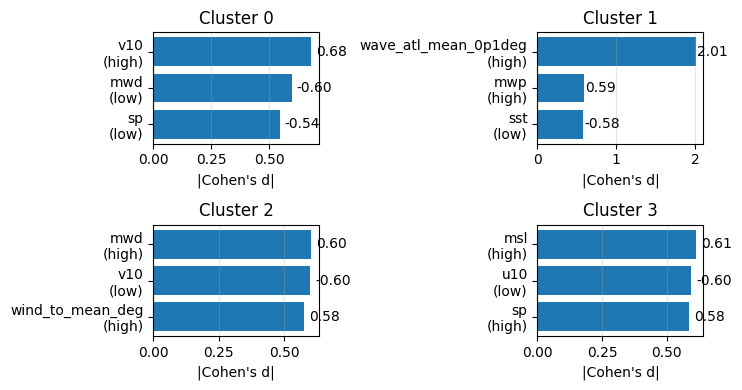

In [132]:
df=model_df.copy()

drop_cols = {"station", "cluster_x", "cluster_y"}
#drop_cols = {"station"}
forbidden_substrings = ("sea_level","CATCH", "catch", "river", "ID", "bay", "current", "bearing", "slope", "curvature", "corridor", "aspect", "coastal", "residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed", "name", "Unnamed", 'HYRIV' , "gev", "ks", "kuiper", "r2", "dist_to_CVI_m",
                        "dist_to_morpho_m", "H", 'HYRIV_ID', "HYR", "GEOM", "POINT", "index", "geometry")
# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols
df= df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = df.drop(columns={'HYRIV_ID'})

num_cols = df.select_dtypes(include=['number']).columns.tolist()

# remove identifiers if present
exclude = ['cluster_id', 'Unnamed: 0_x']
num_cols = [col for col in num_cols if col not in exclude]

results = []

clusters = df['cluster_id'].dropna().unique()

for cluster in clusters:
    df_cluster = df[df['cluster_id'] == cluster]
    df_rest = df[df['cluster_id'] != cluster]
    
    for col in num_cols:
        d = cohens_d(df_cluster[col], df_rest[col])
        
        results.append({
            'cluster_id': cluster,
            'variable': col,
            'cohens_d': d,
            'abs_d': abs(d)
        })

effect_df = pd.DataFrame(results)

# top 3 per cluster
top_features = (
    effect_df
    .sort_values(["cluster_id", "abs_d"], ascending=[True, False])
    .groupby("cluster_id", group_keys=False)
    .head(3)
    .copy()
)

plot_df = top_features.copy()
clusters = sorted(plot_df["cluster_id"].unique())

ncols = 2
nrows = math.ceil(len(clusters) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(7.5, 2 * nrows), squeeze=False)
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    ax = axes[i]
    tmp = (
        plot_df[plot_df["cluster_id"] == cluster]
        .sort_values("abs_d", ascending=True)
    )

    ax.barh(range(len(tmp)), tmp["abs_d"])

    ax.set_yticks(range(len(tmp)))
    ax.set_yticklabels([
        f"{v}\n({'high' if d > 0 else 'low'})"
        for v, d in zip(tmp["variable"], tmp["cohens_d"])
    ])

    for j, dval in enumerate(tmp["cohens_d"]):
        ax.text(
            abs(dval) + 0.02,
            j,
            f"{dval:.2f}",
            va="center"
        )

    ax.set_title(f"Cluster {cluster}")
    ax.set_xlabel("|Cohen's d|")
    ax.grid(axis="x", alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [71]:
top_features = (
    effect_df
    .sort_values(['cluster_id', 'abs_d'], ascending=[True, False])
    .groupby('cluster_id')
    .head(3)
    .copy()
)

In [72]:
top_features['direction'] = top_features['cohens_d'].apply(
    lambda x: 'HIGHER than others' if x > 0 else 'LOWER than others'
)

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_features,
    x='cluster_id',
    y='abs_d',
    hue='label'
)

plt.title('Top 3 Distinguishing Variables per Cluster (Cohen’s d)')
plt.ylabel('Effect size (|Cohen’s d|)')
plt.xlabel('Cluster ID')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `label` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [39]:
top_features['label'] = (
    top_features['variable'] + '\n(' + top_features['direction'] + ')'
)

ValueError: Could not interpret value `label` for `y`. An entry with this name does not appear in `data`.

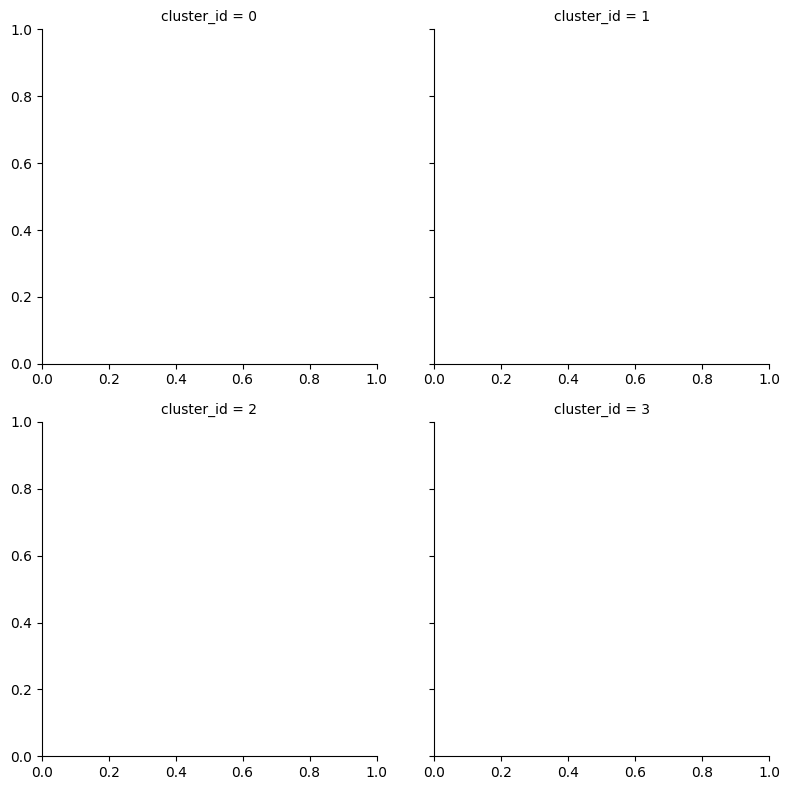

In [67]:
g = sns.FacetGrid(top_features, col="cluster_id", col_wrap=2, height=4, sharex=False)

g.map_dataframe(
    sns.barplot,
    x='abs_d',
    y='label'
)

g.set_axis_labels("Effect size (|d|)", "")
g.set_titles("Cluster {col_name}")

plt.tight_layout()
plt.show()

In [28]:
results = []

clusters = df['cluster_id'].dropna().unique()

for cluster in clusters:
    df_cluster = df[df['cluster_id'] == cluster]
    df_rest = df[df['cluster_id'] != cluster]
    
    for col in num_cols:
        d = cohens_d(df_cluster[col], df_rest[col])
        
        results.append({
            'cluster_id': cluster,
            'variable': col,
            'cohens_d': d,
            'abs_d': abs(d)
        })

effect_df = pd.DataFrame(results)

In [32]:
top_features = (
    effect_df
    .sort_values(['cluster_id', 'abs_d'], ascending=[True, False])
    .groupby('cluster_id')
    .head(4)
)

print(top_features)

    cluster_id                            variable  cohens_d     abs_d
1            0                      wind_wave_diff -0.382319  0.382319
0            0  bearing_deg_0.1x0.1_minus_wind_dir  0.105847  0.105847
3            0                            wind_dir  0.088207  0.088207
2            0                                 swh  0.029531  0.029531
14           1                                 swh  0.521156  0.521156
12           1  bearing_deg_0.1x0.1_minus_wind_dir  0.462132  0.462132
13           1                      wind_wave_diff  0.197331  0.197331
15           1                            wind_dir -0.108669  0.108669
5            2                      wind_wave_diff  0.408668  0.408668
4            2  bearing_deg_0.1x0.1_minus_wind_dir -0.285035  0.285035
7            2                            wind_dir -0.116366  0.116366
6            2                                 swh -0.032835  0.032835
10           3                                 swh -0.465905  0.465905
9     

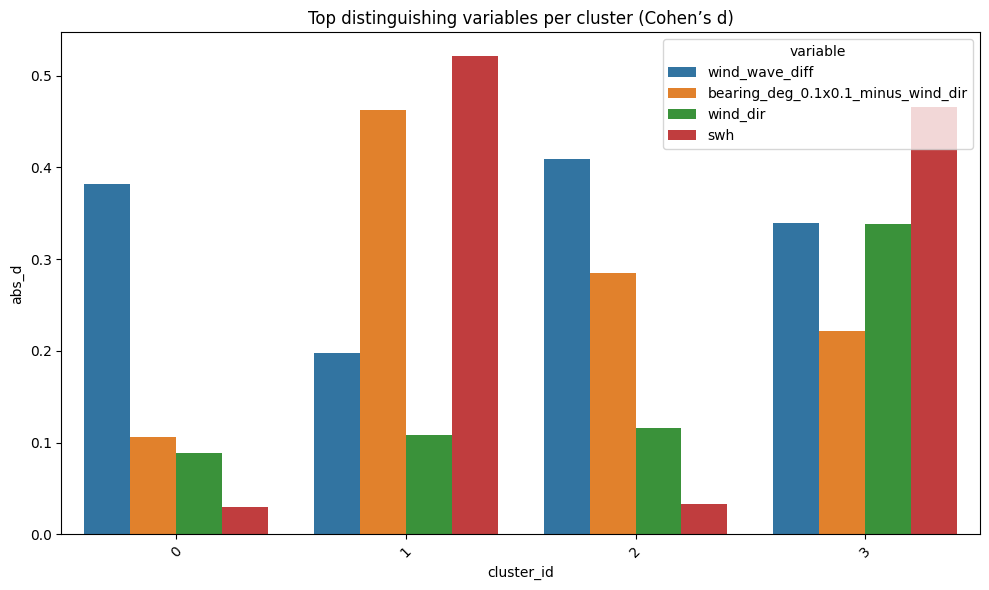

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='cluster_id', y='abs_d', hue='variable')
plt.title('Top distinguishing variables per cluster (Cohen’s d)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [133]:
import scipy.stats as stats

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

ct_table = pd.crosstab(df['cluster_id'], df['coastal_type'])
cramers_v(ct_table)

KeyError: 'coastal_type'